In [1]:
from resources.imports import *

In [2]:
def LHS_uniform(var, strats, lim, mean=0, plot=False):
    lower_limits = np.linspace(mean-lim, mean+lim, strats, endpoint=False)
    upper_limits = lower_limits + ((lower_limits[-1] - lower_limits[0])/(len(lower_limits)-1))
    
    points = np.zeros((strats, var))
    for i in range(var):
        points[:, i] = np.random.uniform(lower_limits, upper_limits, size=strats)
        np.random.shuffle(points[:, i])
    if plot:
        plot_LHS(points, lim, np.append(lower_limits, upper_limits))
    return points

def LHS_scipy(var, strats, lim, opt=None, plot=False):
    sampler = scipy.stats.qmc.LatinHypercube(d=var, optimization=opt)
    points = sampler.random(n=strats)
    discrepancy = scipy.stats.qmc.discrepancy(points)
    points = scipy.stats.qmc.scale(points, -0.2, 0.2)
    if plot:
        plot_LHS(points, lim, np.linspace(-lim, lim, len(points[:,0])+1))
    return points, discrepancy, sampler

def plot_LHS(p, lim, ticks, dims=[0, 1]):
    plt.figure(figsize=(6, 6))
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.xlabel("$\Delta x_i$")
    plt.ylabel("$\Delta y_i$")
    plt.scatter(p[:, dims[0]], p[:, dims[1]], c="r")
    plt.grid()
    plt.show()

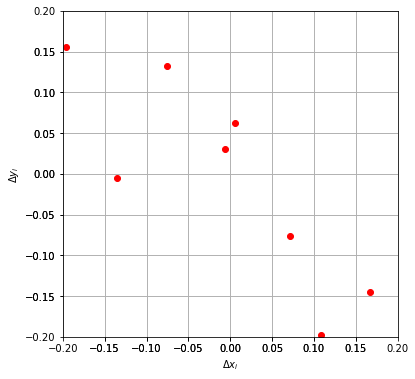

In [5]:
points = LHS_uniform(var=4, strats=8, lim=0.2, plot=True)

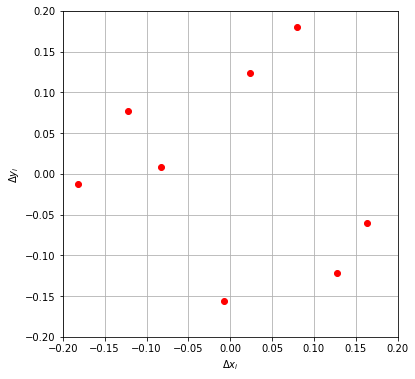

In [6]:
points, discrepency, sampler = LHS_scipy(var=4, strats=8, lim=0.2, plot=True)

[-0.1  0.   0.1  0.2] [-0.2 -0.1  0.   0.1]


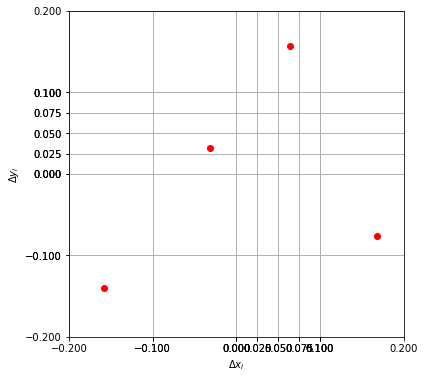

array([[-0.15819967, -0.14022128,  0.06387518,  0.06936999],
       [ 0.06368882,  0.15720404, -0.01670755,  0.10134025],
       [ 0.16831273, -0.07660694,  0.15461054, -0.17409257],
       [-0.03096834,  0.03162435, -0.14011364, -0.07984445]])

In [7]:
def LHS_refined(vars, strats, lim, mean=0, plot=False, refined=False):
    lower_limits = np.linspace(mean-lim, mean+lim, strats, endpoint=False)
    upper_limits = lower_limits + (lower_limits[1] - lower_limits[0])
    
    xticks, yticks = np.append(lower_limits, upper_limits), np.append(lower_limits, upper_limits)

    if refined:

        for i, lims in enumerate(refined):
            lower_limits_ = np.linspace(lims[0], lims[1], strats, endpoint=False)
            upper_limits_ = lower_limits_ + (lower_limits_[1] - lower_limits_[0])

            ticks_ = np.append(lower_limits_, upper_limits_)
            if i == 0:
                xticks = np.append(xticks, ticks_)
            elif i == 1:
                yticks = np.append(yticks, ticks_)
    ticks = np.array([xticks, yticks])
    
    print(upper_limits, lower_limits)

    points = np.zeros((strats, vars))
    for i in range(vars):
        points[:, i] = np.random.uniform(lower_limits, upper_limits, size=strats)
        np.random.shuffle(points[:, i])
    
    if plot:
        plot_LHS(points, lim, ticks[0])

    return points

LHS_refined(vars=4, strats=4, lim=0.2, plot=True, refined=[[0, 0.1], [-0.1, 0]])